In [2]:
!pip install quickdraw

In [3]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from quickdraw import QuickDrawDataGroup

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

In [4]:
IMAGE_SIZE = 128
EMBEDDING_SIZE = 128

categories = [
    "backpack",
    "bed",
    "book",
    "chair",
    "clock",
    "cup",
    "door",
    "key",
    "knife",
    "laptop",
    "shoe",
    "spoon",
    "table",
    "television",
    "toothbrush"
]

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: cpu


In [6]:
class SupConObjectCNN(nn.Module):
    def __init__(
        self,
        num_classes,
        embedding_size=128
    ):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                1,
                16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten()
        )

        self.embedding = nn.Sequential(
            nn.Linear(
                32 * 32 * 32,
                embedding_size
            ),
            nn.ReLU()
        )

        self.classifier = nn.Linear(
            embedding_size,
            num_classes
        )

    def get_embedding(self, x):
        features = self.features(x)
        embedding = self.embedding(features)

        return embedding

    def forward(self, x):
        embedding = self.get_embedding(x)
        logits = self.classifier(embedding)

        return logits, embedding

In [7]:
ORIGINAL_SUPCON_PATH = Path(
    "/content/objects_cnn_supcon_model.pt"
)

model = SupConObjectCNN(
    num_classes=len(categories),
    embedding_size=EMBEDDING_SIZE
).to(device)

model.load_state_dict(
    torch.load(
        ORIGINAL_SUPCON_PATH,
        map_location=device
    )
)

model.eval()

print("Loaded original SupCon model.")

Loaded original SupCon model.


In [8]:
ORIGINAL_SUPCON_PATH = Path(
    "/content/objects_cnn_supcon_model.pt"
)

model = SupConObjectCNN(
    num_classes=len(categories),
    embedding_size=EMBEDDING_SIZE
).to(device)

model.load_state_dict(
    torch.load(
        ORIGINAL_SUPCON_PATH,
        map_location=device
    )
)

model.eval()

print("Loaded original SupCon model.")

Loaded original SupCon model.


In [9]:
centroids_by_k = {}

for k in [1, 5, 10]:
    path = f"/content/objects_supcon_{k}.npz"

    data = np.load(path)

    centroids_by_k[k] = {
        class_name: data[class_name]
        for class_name in data.files
    }

print("Loaded centroids.")

Loaded centroids.


In [10]:
BASE_DRAWINGS_DIR = Path("/content")

def manual_image_to_array_cropped(
    image_path,
    image_size=IMAGE_SIZE,
    padding=10
):
    image = Image.open(
        image_path
    ).convert("L")

    array = np.array(
        image
    ).astype(np.float32)

    # Invert: black background, white strokes
    array = 255.0 - array

    # Find drawing bounds
    mask = array > 20

    if mask.any():
        rows, cols = np.where(mask)

        top = max(rows.min() - padding, 0)
        bottom = min(
            rows.max() + padding + 1,
            array.shape[0]
        )

        left = max(cols.min() - padding, 0)
        right = min(
            cols.max() + padding + 1,
            array.shape[1]
        )

        array = array[
            top:bottom,
            left:right
        ]

    # Put drawing on square canvas
    image = Image.fromarray(
        array.astype(np.uint8)
    )

    width, height = image.size
    side = max(width, height)

    canvas = Image.new(
        "L",
        (side, side),
        color=0
    )

    x = (side - width) // 2
    y = (side - height) // 2

    canvas.paste(
        image,
        (x, y)
    )

    # Resize to model input size
    canvas = canvas.resize(
        (image_size, image_size),
        Image.Resampling.LANCZOS
    )

    array = np.array(
        canvas
    ).astype(np.float32)

    array = array / 255.0

    return array

In [11]:
similarity_tables = {}

model.eval()

for k in [1, 5, 10]:

    rows = []
    drawing_names = []

    for true_class in categories:
        for quality in ["good", "bad"]:

            image_path = (
                BASE_DRAWINGS_DIR
                / f"{true_class}_{quality}.jpg"
            )

            img = manual_image_to_array_cropped(
                image_path
            )

            input_tensor = torch.tensor(
                img,
                dtype=torch.float32
            ).unsqueeze(0).unsqueeze(0).to(device)

            with torch.no_grad():
                _, embedding = model(input_tensor)

            embedding = F.normalize(
                embedding,
                dim=1
            ).cpu().numpy()[0]

            scores = []

            for class_name in categories:

                centroids = centroids_by_k[k][
                    class_name
                ]

                similarities = (
                    centroids @ embedding
                )

                # Best similarity to this class
                score = similarities.max()

                scores.append(float(score))

            rows.append(scores)

            drawing_names.append(
                f"{true_class}_{quality}"
            )

    similarity_tables[k] = pd.DataFrame(
        rows,
        index=drawing_names,
        columns=categories
    ).round(3)

    similarity_tables[k].index.name = "drawing"

In [12]:
display(
    similarity_tables[1]
)

,backpack,bed,book,chair,clock,cup,door,key,knife,laptop,shoe,spoon,table,television,toothbrush
drawing,,,,,,,,,,,,,,,
backpack_good,0.689,0.752,0.852,0.655,0.475,0.761,0.608,0.620,0.616,0.836,0.728,0.566,0.635,0.898,0.572
backpack_bad,0.955,0.632,0.701,0.519,0.689,0.691,0.514,0.589,0.511,0.585,0.607,0.496,0.558,0.685,0.493
bed_good,0.779,0.792,0.924,0.685,0.533,0.848,0.690,0.692,0.695,0.714,0.726,0.651,0.713,0.767,0.680
bed_bad,0.657,0.825,0.749,0.812,0.460,0.707,0.621,0.644,0.698,0.735,0.689,0.621,0.679,0.772,0.648
book_good,0.798,0.878,0.885,0.742,0.569,0.879,0.694,0.737,0.723,0.744,0.779,0.672,0.748,0.787,0.709
book_bad,0.763,0.727,0.947,0.607,0.520,0.791,0.638,0.624,0.596,0.674,0.680,0.548,0.657,0.760,0.555
chair_good,0.705,0.839,0.776,0.886,0.521,0.813,0.736,0.715,0.748,0.732,0.752,0.696,0.723,0.698,0.726
chair_bad,0.525,0.664,0.591,0.846,0.389,0.632,0.565,0.646,0.824,0.600,0.618,0.752,0.554,0.563,0.795
clock_good,0.938,0.749,0.730,0.611,0.689,0.740,0.563,0.639,0.587,0.628,0.660,0.556,0.618,0.638,0.582


In [13]:
summary_rows = []

for drawing_name, row in similarity_tables[1].iterrows():

    true_class = drawing_name.rsplit("_", 1)[0]

    predicted_class = row.idxmax()
    top_score = row.max()
    correct_score = row[true_class]

    summary_rows.append({
        "drawing": drawing_name,
        "true_class": true_class,
        "predicted_class": predicted_class,
        "correct_score": correct_score,
        "top_score": top_score,
        "correct": predicted_class == true_class
    })

summary_df = pd.DataFrame(summary_rows)

display(summary_df)

,drawing,true_class,predicted_class,correct_score,top_score,correct
0,backpack_good,backpack,television,0.689,0.898,False
1,backpack_bad,backpack,backpack,0.955,0.955,True
2,bed_good,bed,book,0.792,0.924,False
3,bed_bad,bed,bed,0.825,0.825,True
4,book_good,book,book,0.885,0.885,True
5,book_bad,book,book,0.947,0.947,True
6,chair_good,chair,chair,0.886,0.886,True
7,chair_bad,chair,chair,0.846,0.846,True
8,clock_good,clock,backpack,0.689,0.938,False
9,clock_bad,clock,backpack,0.707,0.945,False


In [14]:
!pip install -q gradio

# New Section

In [15]:
import gradio as gr

In [16]:
def gradio_image_to_array_cropped(
    editor_value,
    image_size=IMAGE_SIZE,
    padding=10
):
    if editor_value is None:
        return None

    # ImageEditor usually returns a dictionary
    if isinstance(editor_value, dict):
        image = editor_value.get("composite")

        if image is None:
            image = editor_value.get("background")
    else:
        image = editor_value

    if image is None:
        return None

    # Convert numpy array to PIL
    if isinstance(image, np.ndarray):
        image = Image.fromarray(
            image.astype(np.uint8)
        )

    # Convert to grayscale
    image = image.convert("L")

    array = np.array(
        image
    ).astype(np.float32)

    # White background -> 0
    # Black drawing -> 255
    array = 255.0 - array

    # Find drawing
    mask = array > 20

    if mask.any():
        rows, cols = np.where(mask)

        top = max(rows.min() - padding, 0)
        bottom = min(
            rows.max() + padding + 1,
            array.shape[0]
        )

        left = max(cols.min() - padding, 0)
        right = min(
            cols.max() + padding + 1,
            array.shape[1]
        )

        array = array[
            top:bottom,
            left:right
        ]

    # Make square
    image = Image.fromarray(
        array.astype(np.uint8)
    )

    width, height = image.size
    side = max(width, height)

    canvas = Image.new(
        "L",
        (side, side),
        color=0
    )

    x = (side - width) // 2
    y = (side - height) // 2

    canvas.paste(
        image,
        (x, y)
    )

    # Resize to CNN input
    canvas = canvas.resize(
        (image_size, image_size),
        Image.Resampling.LANCZOS
    )

    array = (
        np.array(canvas).astype(np.float32)
        / 255.0
    )

    return array

In [17]:
def predict_drawing(editor_value, k):

    img = gradio_image_to_array_cropped(
        editor_value
    )

    if img is None:
        return "Draw something first!", None, None

    input_tensor = torch.tensor(
        img,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        _, embedding = model(
            input_tensor
        )

    embedding = F.normalize(
        embedding,
        dim=1
    ).cpu().numpy()[0]

    scores = {}

    for class_name in categories:

        class_centroids = (
            centroids_by_k[int(k)][class_name]
        )

        similarities = (
            class_centroids @ embedding
        )

        scores[class_name] = float(
            similarities.max()
        )

    predicted_class = max(
        scores,
        key=scores.get
    )

    top_score = scores[predicted_class]

    score_df = pd.DataFrame({
        "Class": categories,
        "Cosine Similarity": [
            scores[class_name]
            for class_name in categories
        ]
    })

    score_df = score_df.sort_values(
        "Cosine Similarity",
        ascending=False
    ).reset_index(drop=True)

    return (
        predicted_class,
        round(top_score, 4),
        score_df
    )

In [18]:
white_canvas = Image.new(
    "RGB",
    (500, 500),
    "white"
)

with gr.Blocks() as demo:

    gr.Markdown(
        "# CrAIons - Objects Model"
    )

    drawing = gr.ImageEditor(
    value=white_canvas,
    type="pil",
    label="Draw an object",
    brush=gr.Brush(
        default_size=3,
        colors=["black"],
        default_color="black",
        color_mode="fixed"
    )
)

    k_choice = gr.Dropdown(
        choices=[1, 5, 10],
        value=1,
        label="Number of Centroids (k)"
    )

    predict_button = gr.Button(
        "Predict"
    )

    predicted_output = gr.Textbox(
        label="Predicted Class"
    )

    similarity_output = gr.Number(
        label="Top Cosine Similarity"
    )

    scores_output = gr.Dataframe(
        headers=[
            "Class",
            "Cosine Similarity"
        ],
        label="Similarity to All 15 Classes"
    )

    predict_button.click(
        fn=predict_drawing,
        inputs=[
            drawing,
            k_choice
        ],
        outputs=[
            predicted_output,
            similarity_output,
            scores_output
        ]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5130286ac923da7c59.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [20]:
def plot_embedding_space(
    user_embedding,
    correct_class,
    k=1
):
    all_embeddings = []
    labels = []
    point_types = []

    # Add category centroids
    for class_name in categories:

        centroids = centroids_by_k[k][class_name]

        for centroid in centroids:
            all_embeddings.append(centroid)
            labels.append(class_name)

            if class_name == correct_class:
                point_types.append("correct")
            else:
                point_types.append("incorrect")

    # Add user's drawing
    all_embeddings.append(user_embedding)
    labels.append("User Drawing")
    point_types.append("user")

    all_embeddings = np.array(all_embeddings)

    # Reduce 128D -> 2D
    pca = PCA(n_components=2)

    points_2d = pca.fit_transform(
        all_embeddings
    )

    plt.figure(figsize=(9, 7))

    for i, point_type in enumerate(point_types):

        x = points_2d[i, 0]
        y = points_2d[i, 1]

        if point_type == "incorrect":
            plt.scatter(
                x,
                y,
                color="red",
                s=80
            )

        elif point_type == "correct":
            plt.scatter(
                x,
                y,
                color="green",
                s=120
            )

        else:
            plt.scatter(
                x,
                y,
                color="blue",
                s=120
            )

        # Label the class
        plt.annotate(
            labels[i],
            (x, y),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )

    # Axis lines like your drawing
    plt.axhline(
        0,
        color="black",
        linewidth=0.7
    )

    plt.axvline(
        0,
        color="black",
        linewidth=0.7
    )

    # Legend
    plt.scatter(
        [],
        [],
        color="red",
        label="Incorrect classes"
    )

    plt.scatter(
        [],
        [],
        color="green",
        label="Correct class"
    )

    plt.scatter(
        [],
        [],
        color="blue",
        label="User drawing"
    )

    plt.legend()

    plt.title(
        "128D Embedding Space Visualized in 2D"
    )

    plt.xlabel("PCA Dimension 1")
    plt.ylabel("PCA Dimension 2")

    plt.show()

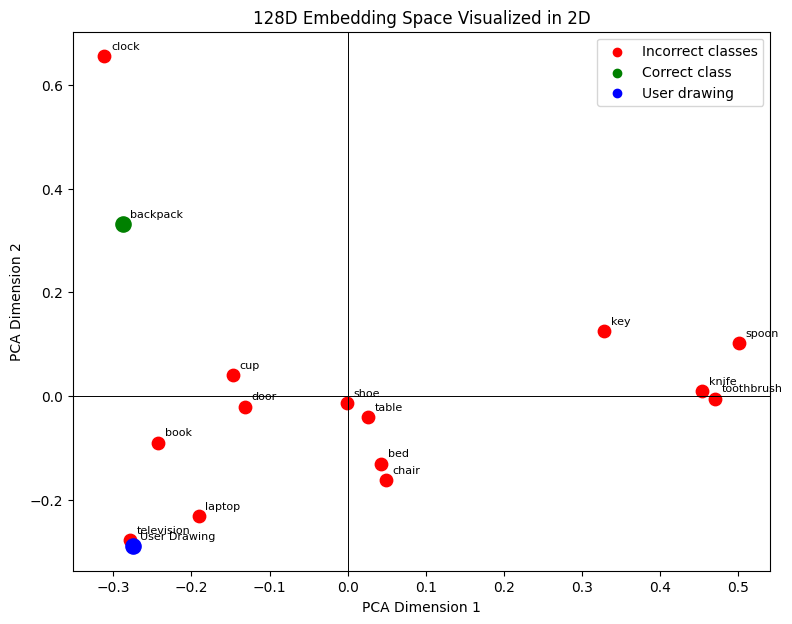

In [21]:
image_path = (
    BASE_DRAWINGS_DIR
    / "backpack_good.jpg"
)

img = manual_image_to_array_cropped(
    image_path
)

input_tensor = torch.tensor(
    img,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    _, embedding = model(
        input_tensor
    )

embedding = F.normalize(
    embedding,
    dim=1
).cpu().numpy()[0]

plot_embedding_space(
    user_embedding=embedding,
    correct_class="backpack",
    k=1
)

In [23]:
pairs = []

for i, class_a in enumerate(categories):

    for j in range(
        i + 1,
        len(categories)
    ):

        class_b = categories[j]

        similarity = class_similarity.loc[
            class_a,
            class_b
        ]

        pairs.append({
            "class_1": class_a,
            "class_2": class_b,
            "cosine_similarity": similarity
        })

closest_pairs = (
    pd.DataFrame(pairs)
    .sort_values(
        "cosine_similarity",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    closest_pairs.round(3)
)

,class_1,class_2,cosine_similarity
0,knife,spoon,0.916
1,knife,toothbrush,0.908
2,key,spoon,0.892
3,bed,table,0.877
4,book,cup,0.842
...,...,...,...
100,clock,television,0.458
101,chair,clock,0.430
102,clock,knife,0.427
103,clock,spoon,0.421
